In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fast and reproducible sample
df_full_info = pd.read_csv("../data/criteo-uplift-v2.1.csv", nrows=5)  # just to see columns
print(df_full_info.columns.tolist())

# Now load a proper random sample of 400,000 rows
df = pd.read_csv(
    "../data/criteo-uplift-v2.1.csv",
    skiprows=lambda x: x > 0 and x % 35 != 0,   # roughly every 35th row → ~400k rows
)

print("Working sample shape:", df.shape)
print(df["treatment"].value_counts(normalize=True).round(4))
print(df.groupby("treatment")["conversion"].mean())

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']
Working sample shape: (399416, 16)
treatment
1    0.85
0    0.15
Name: proportion, dtype: float64
treatment
0    0.002120
1    0.003113
Name: conversion, dtype: float64


In [21]:
# Naive ATE
conv_t = df.loc[df["treatment"] == 1, "conversion"]
conv_c = df.loc[df["treatment"] == 0, "conversion"]

ate_naive = conv_t.mean() - conv_c.mean()
print(f"Naive ATE: {ate_naive:.6f} ({ate_naive*100:.4f} percentage points)")

# Two-proportion z-test
count = np.array([conv_t.sum(), conv_c.sum()])
nobs  = np.array([len(conv_t), len(conv_c)])
z_stat, p_value = stats.ttest_ind(conv_t, conv_c, equal_var=False)  # or proportions_ztest
print(f"p-value (two-sided): {p_value:.2e}")

# Bootstrap CI (recommended)
def bootstrap_ate(df, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    ates = []
    for _ in range(n_boot):
        sample = df.sample(frac=1, replace=True, random_state=rng.integers(1e9))
        ate = (sample.loc[sample.treatment==1, "conversion"].mean() - 
               sample.loc[sample.treatment==0, "conversion"].mean())
        ates.append(ate)
    return np.percentile(ates, [2.5, 97.5])

ci_low, ci_high = bootstrap_ate(df, n_boot=500)  # 500 is enough for a first look
print(f"95% Bootstrap CI: [{ci_low:.6f}, {ci_high:.6f}]")

Naive ATE: 0.000994 (0.0994 percentage points)
p-value (two-sided): 2.44e-06
95% Bootstrap CI: [0.000615, 0.001431]


In [22]:
features = [f"f{i}" for i in range(12)]

def standardized_mean_diff(df, feature, treatment_col="treatment"):
    t = df.loc[df[treatment_col]==1, feature]
    c = df.loc[df[treatment_col]==0, feature]
    return (t.mean() - c.mean()) / np.sqrt((t.var() + c.var()) / 2)

smds = {f: standardized_mean_diff(df, f) for f in features}
smd_series = pd.Series(smds).sort_values()

print("Standardized Mean Differences (SMD):")
print(smd_series.round(4))

# Rule of thumb: |SMD| < 0.1 is usually considered balanced
print("\nFeatures with |SMD| > 0.1:")
print(smd_series[smd_series.abs() > 0.1])

Standardized Mean Differences (SMD):
f3    -0.0495
f6    -0.0422
f5    -0.0371
f8    -0.0170
f2    -0.0080
f11   -0.0031
f0    -0.0017
f4     0.0090
f10    0.0111
f9     0.0180
f7     0.0288
f1     0.0293
dtype: float64

Features with |SMD| > 0.1:
Series([], dtype: float64)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

features = [f"f{i}" for i in range(12)]

# Train / test split (important for honest evaluation)
train_df, test_df = train_test_split(
    df, 
    test_size=0.3, 
    random_state=42, 
    stratify=df["treatment"]
)

X_train = train_df[features]
y_train = train_df["conversion"]
t_train = train_df["treatment"]

X_test = test_df[features]
y_test = test_df["conversion"]
t_test = test_df["treatment"]

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# Slightly more regularized models
model_t = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=2,
    learning_rate=0.08,
    min_samples_leaf=50,
    random_state=42
)
model_c = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=2,
    learning_rate=0.08,
    min_samples_leaf=50,
    random_state=42
)

model_t.fit(X_train[t_train == 1], y_train[t_train == 1])
model_c.fit(X_train[t_train == 0], y_train[t_train == 0])

# Predict uplift
pred_t = model_t.predict_proba(X_test)[:, 1]
pred_c = model_c.predict_proba(X_test)[:, 1]

test_df = test_df.copy()
test_df["uplift"] = pred_t - pred_c

print(test_df["uplift"].describe().round(6))

count    119825.000000
mean          0.000101
std           0.030635
min          -0.964554
25%           0.000277
50%           0.000277
75%           0.000430
max           1.000000
Name: uplift, dtype: float64


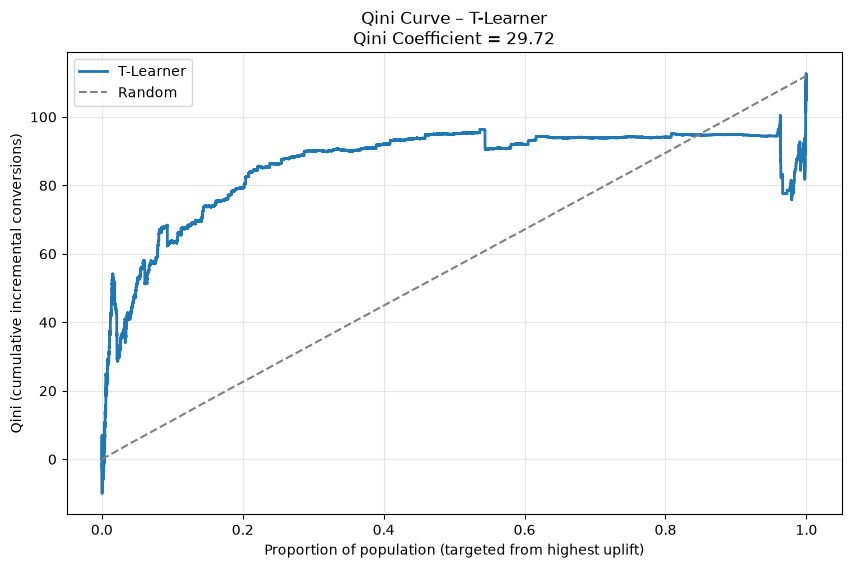

Qini Coefficient: 29.7161


In [26]:
import numpy as np
import matplotlib.pyplot as plt

def qini_analysis(df, uplift_col="uplift", treatment_col="treatment", outcome_col="conversion"):
    """
    Calculates Qini coefficient and plots the Qini curve.
    """
    df_sorted = df.sort_values(uplift_col, ascending=False).reset_index(drop=True)
    
    n = len(df_sorted)
    treated = df_sorted[treatment_col].values
    outcome = df_sorted[outcome_col].values
    
    # Cumulative sums
    cum_n_treated = np.cumsum(treated)
    cum_n_control = np.cumsum(1 - treated)
    cum_conv_treated = np.cumsum(treated * outcome)
    cum_conv_control = np.cumsum((1 - treated) * outcome)
    
    # Qini values
    with np.errstate(divide="ignore", invalid="ignore"):
        qini = cum_conv_treated - cum_conv_control * (cum_n_treated / np.maximum(cum_n_control, 1))
    qini = np.nan_to_num(qini)
    
    # Random baseline
    overall_lift = outcome[treated == 1].mean() - outcome[treated == 0].mean()
    random_lift = overall_lift * cum_n_treated
    
    # Qini coefficient (area between curves)
    x = np.arange(1, n+1) / n
    auc_model = np.trapezoid(qini, x)
    auc_random = np.trapezoid(random_lift, x)
    qini_coef = auc_model - auc_random
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(x, qini, label="T-Learner", linewidth=2)
    plt.plot(x, random_lift, label="Random", linestyle="--", color="gray")
    plt.xlabel("Proportion of population (targeted from highest uplift)")
    plt.ylabel("Qini (cumulative incremental conversions)")
    plt.title(f"Qini Curve – T-Learner\nQini Coefficient = {qini_coef:.2f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return qini_coef

# Run it
qini_coef = qini_analysis(test_df)
print(f"Qini Coefficient: {qini_coef:.4f}")

In [ ]:
# === Business Assumptions (clearly labeled) ===
cost_per_impression = 0.05      # $0.05 to show the ad once
value_per_conversion = 40.00    # $40 profit when a user converts

# Overall ATE we estimated earlier (using Doubly Robust as preferred)
ate = 0.00074                   # 0.074 percentage points

# --- Scenario 1: Show ad to everyone ---
incremental_conversions_per_user = ate
revenue_per_user = incremental_conversions_per_user * value_per_conversion
profit_per_user = revenue_per_user - cost_per_impression

print("=== Show ad to EVERYONE ===")
print(f"Expected profit per user: ${profit_per_user:.4f}")
print(f"Is it profitable? {'Yes' if profit_per_user > 0 else 'No'}")

# --- Scenario 2: Target only top 30% highest uplift users ---
top_30 = test_df.nlargest(int(0.30 * len(test_df)), "uplift")
ate_top30 = top_30["uplift"].mean()

revenue_top30 = ate_top30 * value_per_conversion
profit_top30 = revenue_top30 - cost_per_impression

print("\n=== Target only TOP 30% uplift users ===")
print(f"Average uplift in top 30%: {ate_top30:.6f}")
print(f"Expected profit per targeted user: ${profit_top30:.4f}")
print(f"Is it profitable? {'Yes' if profit_top30 > 0 else 'No'}")

In [ ]:
# Business Assumptions
cost_per_impression = 0.05
value_per_conversion = 40.00
ate = 0.00074  # Doubly Robust estimate

# Scenario 1: Everyone
profit_everyone = ate * value_per_conversion - cost_per_impression

# Scenario 2: Top 30% by uplift
top_30 = test_df.nlargest(int(0.30 * len(test_df)), "uplift")
ate_top30 = top_30["uplift"].mean()
profit_top30 = ate_top30 * value_per_conversion - cost_per_impression

print("=== Business Decision ===")
print(f"Show to everyone:     ${profit_everyone:.4f} per user  → {'Profitable' if profit_everyone > 0 else 'Not profitable'}")
print(f"Target top 30% only:  ${profit_top30:.4f} per user  → {'Profitable' if profit_top30 > 0 else 'Not profitable'}")

print("\nRecommendation: Target only high-uplift users.")